In [1]:
import matplotlib.pyplot as plt
%matplotlib inline
from IPython.core.pylabtools import figsize

import seaborn as sns

import numpy as np
import pandas as pd

from tqdm import tqdm

In [2]:
sheets_df = pd.read_parquet('fetched.parquet')
sheets_df['fiscal_year'] = sheets_df['fiscal_year'].astype(int)

In [3]:
from fetch_data import clean_and_dedup_data


full_data = pd.read_parquet('fetched.parquet')

# part of basic cleaning
full_data['fiscal_year'] = full_data['fiscal_year'].astype(int)
full_data['period_start'] = pd.to_datetime(full_data['period_start'], unit='s')
full_data['period_end'] = pd.to_datetime(full_data['period_end'], unit='s')

In [4]:
import pandas as pd

from edgar import set_identity, Company, reference
from edgar.enums import PeriodType


from rich.progress import track

# set to proper id for edgar usage
id = "Luke Rast luke.rast@gmail.com"
set_identity(id)



# Testing / double checks

## Make sure that data collected in the sweep is the same as individual collections.

In [5]:
company = Company('WMT')
facts = company.get_facts()

def query(): return facts.query().by_form_type('10-K')


# market data reported on the 10-K
public_float = query().by_concept('dei:EntityPublicFloat').to_dataframe()
public_float = clean_and_dedup_data(public_float)

shares_outstanding = query().by_concept('dei:EntityCommonStockSharesOutstanding').to_dataframe()
shares_outstanding = clean_and_dedup_data(shares_outstanding)

# other data
financials_data = query().by_period_type(PeriodType.ANNUAL).to_dataframe()
financials_data = clean_and_dedup_data(financials_data)

balance_data = query().by_statement_type("BalanceSheet").to_dataframe()
balance_data = clean_and_dedup_data(balance_data)

data = pd.concat([public_float, shares_outstanding, financials_data, balance_data])
data['cik'] = company.cik
data['company'] = company.name

In [6]:
data

,concept,label,value,numeric_value,unit,scale,period_start,period_end,period_type,fiscal_year,fiscal_period,form_type,data_quality,confidence_score,is_audited,is_estimated,statement_type,cik,company
0,dei:EntityPublicFloat,Entity Public Float,1.074994e+11,1.074994e+11,USD,None,None,2009-07-31,instant,2009,FY,10-K,high,0.9,True,False,None,104169,Walmart Inc.
1,dei:EntityPublicFloat,Entity Public Float,9.933998e+10,9.933998e+10,USD,None,None,2010-07-30,instant,2010,FY,10-K,high,0.9,True,False,None,104169,Walmart Inc.
2,dei:EntityPublicFloat,Entity Public Float,9.170454e+10,9.170454e+10,USD,None,None,2011-07-29,instant,2011,FY,10-K,high,0.9,True,False,None,104169,Walmart Inc.
3,dei:EntityPublicFloat,Entity Public Float,1.232869e+11,1.232869e+11,USD,None,None,2012-07-31,instant,2012,FY,10-K,high,0.9,True,False,None,104169,Walmart Inc.
4,dei:EntityPublicFloat,Entity Public Float,1.247527e+11,1.247527e+11,USD,None,None,2013-07-31,instant,2013,FY,10-K,high,0.9,True,False,None,104169,Walmart Inc.
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
948,us-gaap:StockholdersEquity,Stockholders' Equity Attributable to Parent,8.325300e+10,8.325300e+10,USD,None,None,2022-01-31,instant,2022,FY,10-K,high,0.9,True,False,BalanceSheet,104169,Walmart Inc.
950,us-gaap:StockholdersEquity,Stockholders' Equity Attributable to Parent,7.669300e+10,7.669300e+10,USD,None,None,2023-01-31,instant,2023,FY,10-K,high,0.9,True,False,BalanceSheet,104169,Walmart Inc.
952,us-gaap:StockholdersEquity,Stockholders' Equity Attributable to Parent,8.386100e+10,8.386100e+10,USD,None,None,2024-01-31,instant,2024,FY,10-K,high,0.9,True,False,BalanceSheet,104169,Walmart Inc.
954,us-gaap:StockholdersEquity,Stockholders' Equity Attributable to Parent,9.101300e+10,9.101300e+10,USD,None,None,2025-01-31,instant,2025,FY,10-K,high,0.9,True,False,BalanceSheet,104169,Walmart Inc.


In [7]:
full_data = pd.read_parquet('fetched.parquet')
selection = full_data[ full_data['cik'] == 104169]

data = data.reset_index().drop(columns=['index'])
selection = selection.reset_index().drop(columns=['index', 'tickers'])

In [8]:
(selection.fillna(0) == data.fillna(0)).all().all()

np.True_

# Exploration of the data


## 1. Where are the duplicates?

In [9]:
full_data['fiscal_year'] = full_data['fiscal_year'].astype(int)

In [10]:
print('rendundency in period end counts:', full_data.groupby(['concept', 'period_end', 'cik'])['value'].count().unique())

rendundency in period end counts: [1]

In [11]:
print('redundency in fiscal year counts:', full_data.groupby(['concept', 'fiscal_year', 'cik'])['value'].count().unique())

redundency in fiscal year counts: [ 1  2  3  6  4  5  7 23 13  9]

There are duplicated data points for fiscal years, but not period-end. This indicates that the some years are multiply reported with different periods.

__Ans:__ tie-break by the later period-end.

In [12]:
from postprocessing import basic_cleaning
cleaned_data = basic_cleaning(full_data)

print(cleaned_data.groupby(['concept', 'fiscal_year', 'cik'])['value'].count().unique())

[1]

## 2. Are there overlaps between multiple labels / concepts?

In [13]:
(cleaned_data.groupby('concept')['label'].nunique() > 1).any()

np.False_

No concepts have multiple labels

In [14]:
concepts_by_label = cleaned_data.groupby('label')['concept']

print(concepts_by_label.nunique()[(concepts_by_label.nunique() > 1)])

label
    557
Name: concept, dtype: int64

In [36]:
for concepts in (concepts_by_label.unique()[(concepts_by_label.nunique() > 1)]):
    print(concepts)

<ArrowStringArray>
[                                                                     'cef:AnnualCoverageReturnRatePercent',
                                                                            'cef:AnnualInterestRatePercent',
                                                                                 'cef:ExpenseExampleYear01',
                                                                             'cef:ExpenseExampleYears1to10',
                                                                              'cef:ExpenseExampleYears1to3',
                                                                              'cef:ExpenseExampleYears1to5',
                                                                                 'cef:IncentiveFeesPercent',
                                                                  'cef:InterestExpensesOnBorrowingsPercent',
                                                                    'cef:LatestPremiumDiscountToNavPercent',
                                                                             'cef:LoanServicingFeesPercent',
 ...
                           'us-gaap:TimeSharingTransactionsChangesInEstimateAssociatedWithPriorPeriodSales',
                                       'us-gaap:UnrealizedGainLossInvestmentAndDerivativeOperatingAfterTax',
                                      'us-gaap:UnrealizedGainLossInvestmentAndDerivativeOperatingBeforeTax',
                              'us-gaap:UnrealizedGainLossInvestmentAndDerivativeOperatingTaxExpenseBenefit',
             'us-gaap:UnrealizedGainLossInvestmentDerivativeAndForeignCurrencyTransactionOperatingAfterTax',
  'us-gaap:UnrealizedGainLossInvestmentDerivativeAndForeignCurrencyTransactionPriceChangeOperatingAfterTax',
 'us-gaap:UnrealizedGainLossInvestmentDerivativeAndForeignCurrencyTransactionPriceChangeOperatingBeforeTax',
                                                     'us-gaap:UnrealizedGainLossSecuritySoldShortOperating',
                          'us-gaap:WarrantDownRoundFeatureDecreaseInNetIncomeLossToCommonShareholderAmount',
                                           'us-gaap:WarrantDownRoundFeatureIncreaseDecreaseInEquityAmount1']
Length: 529, dtype: str

<ArrowStringArray>
['srt:IncreaseDecreaseInEstimatedFutureDevelopmentCosts', 
'us-gaap:IncreaseDecreaseInEstimatedFutureDevelopmentCosts']
Length: 2, dtype: str

<ArrowStringArray>
['srt:IncreaseDecreaseInFutureIncomeTaxExpenseEstimatesOnFutureCashFlowsRelatedToProvedOilAndGasReserves', 
'us-gaap:IncreaseDecreaseInFutureIncomeTaxExpenseEstimatesOnFutureCashFlowsRelatedToProvedOilAndGasReserves']
Length: 2, dtype: str

<ArrowStringArray>
['srt:DecreaseDueToSalesOfMineralsInPlace', 'us-gaap:DecreaseDueToSalesOfMineralsInPlace']
Length: 2, dtype: str

<ArrowStringArray>
['srt:ExtensionsDiscoveriesAdditionsAndImprovedRecoveryLessRelatedCosts', 
'us-gaap:ExtensionsDiscoveriesAdditionsAndImprovedRecoveryLessRelatedCosts']
Length: 2, dtype: str

...

<ArrowStringArray>
['srt:RevisionsOfPreviousQuantityEstimates', 'us-gaap:RevisionsOfPreviousQuantityEstimates']
Length: 2, dtype: str

<ArrowStringArray>
['srt:SalesAndTransfersOfOilAndGasProducedNetOfProductionCosts', 
'us-gaap:SalesAndTransfersOfOilAndGasProducedNetOfProductionCosts']
Length: 2, dtype: str

<ArrowStringArray>
['srt:StandardizedMeasureOfDiscountedFutureNetCashFlowRelatingToProvedOilAndGasReservesAccretionOfDiscount', 
'us-gaap:StandardizedMeasureOfDiscountedFutureNetCashFlowRelatingToProvedOilAndGasReservesAccretionOfDiscount']
Length: 2, dtype: str

<ArrowStringArray>
['srt:StandardizedMeasureOfDiscountedFutureNetCashFlowOfProvedOilAndGasReservesOther', 
'us-gaap:StandardizedMeasureOfDiscountedFutureNetCashFlowOfProvedOilAndGasReservesOther']
Length: 2, dtype: str

<ArrowStringArray>
['srt:StandardizedMeasureOfDiscountedFutureNetCashFlowOfProvedOilAndGasReservesPeriodIncreaseDecrease', 
'us-gaap:StandardizedMeasureOfDiscountedFutureNetCashFlowOfProvedOilAndGasReservesPeriodIncreaseDecrease']
Length: 2, dtype: str

Other than the unlabeled points, there is only conflict between 'srt:' and 'us-gaap:' prefix: can resolve this in the basic data processing step

In [38]:
def second_part(x): return x.split(':')[1]
for concepts in (concepts_by_label.unique()[(concepts_by_label.nunique() > 1)]):
    if len(concepts) > 2:
        continue
    print( second_part(concepts[0]) == second_part(concepts[1]))
    
    

True

True

True

True

True

...

True

True

True

True

True

This is now incorporated into the postprocessing: it won't reproduce without reverting that.

## 3. How common are the different concepts?

In [15]:
from postprocessing import basic_cleaning

In [16]:
cleaned_data = basic_cleaning(full_data)

In [17]:
cleaned_data.groupby(['concept', 'fiscal_year', 'cik'])['value'].count().unique()

array([1])

In [18]:
income = cleaned_data[cleaned_data['statement_type'] == 'IncomeStatement']
income_concepts = income.pivot(index=['cik', 'fiscal_year'], columns='concept', values='value')

<Axes: xlabel='concept'>

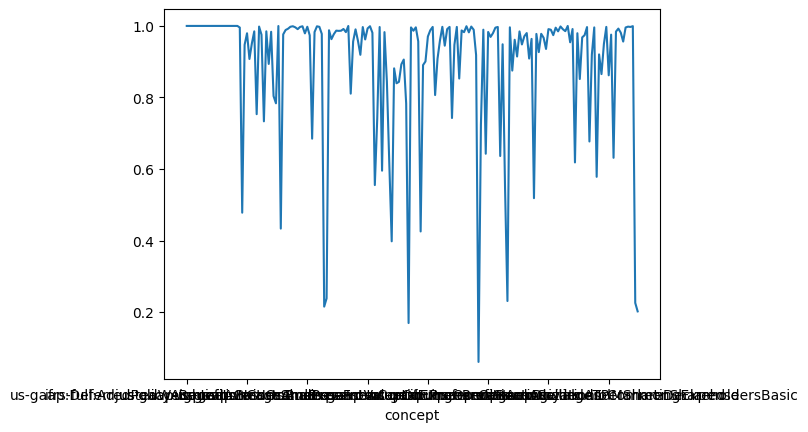

In [19]:
 income_concepts.isna().mean().plot()

Text(0.5, 1.0, 'CDF of concepts with sparsity less than x')

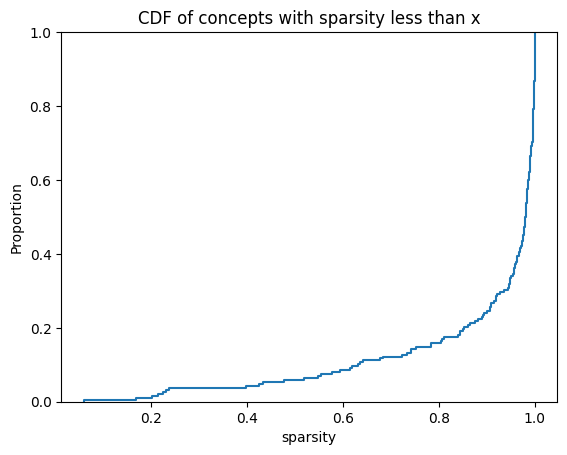

In [20]:
sns.ecdfplot(income_concepts.isna().mean())
plt.xlabel('sparsity')
plt.title('CDF of concepts with sparsity less than x')

We can get quite a lot of column-wise decrease by cutting off at quite high sparsities

In [21]:
income_concepts.columns[ income_concepts.isna().mean() < 0.9]

Index(['us-gaap:AmortizationOfIntangibleAssets',
       'us-gaap:CommonStockDividendsPerShareDeclared',
       'us-gaap:CostOfGoodsAndServicesSold', 'us-gaap:CostOfGoodsSold',
       'us-gaap:CostOfRevenue', 'us-gaap:CostsAndExpenses',
       'us-gaap:CurrentIncomeTaxExpenseBenefit',
       'us-gaap:DepreciationAndAmortization', 'us-gaap:EarningsPerShareBasic',
       'us-gaap:EarningsPerShareDiluted',
       'us-gaap:ForeignCurrencyTransactionGainLossBeforeTax',
       'us-gaap:GeneralAndAdministrativeExpense',
       'us-gaap:GoodwillImpairmentLoss', 'us-gaap:GrossProfit',
       'us-gaap:IncomeLossFromContinuingOperations',
       'us-gaap:IncomeLossFromContinuingOperationsBeforeIncomeTaxesDomestic',
       'us-gaap:IncomeLossFromContinuingOperationsBeforeIncomeTaxesExtraordinaryItemsNoncontrollingInterest',
       'us-gaap:IncomeLossFromContinuingOperationsIncludingPortionAttributableToNoncontrollingInterest',
       'us-gaap:IncomeLossFromContinuingOperationsPerBasicShare',
      

Generally, this is a pretty good, easy filtering mechanism. It has most everything that I could want.

In [22]:
concept_data = cleaned_data.pivot(index=['cik', 'fiscal_year'], columns='concept', values='value')

Text(0.5, 1.0, 'CDF of concepts with sparsity less than x')

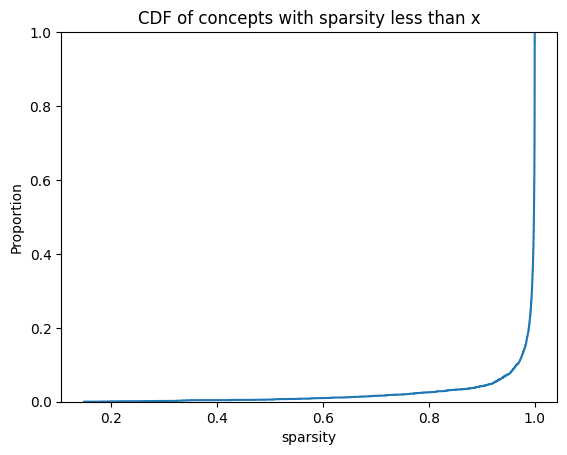

In [23]:
sns.ecdfplot(concept_data.isna().mean())
plt.xlabel('sparsity')
plt.title('CDF of concepts with sparsity less than x')

This behavior is even more severe on the full dataset.

In [24]:
concept_data.columns[ concept_data.isna().mean() < 0.95]

Index(['dei:EntityCommonStockSharesOutstanding', 'dei:EntityPublicFloat',
       'us-gaap:AccountsPayableCurrent', 'us-gaap:AccountsReceivableNet',
       'us-gaap:AccountsReceivableNetCurrent',
       'us-gaap:AccretionAmortizationOfDiscountsAndPremiumsInvestments',
       'us-gaap:AccruedLiabilitiesCurrent',
       'us-gaap:AccumulatedOtherComprehensiveIncomeLossDefinedBenefitPensionAndOtherPostretirementPlansNetOfTax',
       'us-gaap:AccumulatedOtherComprehensiveIncomeLossNetOfTax',
       'us-gaap:AdditionalPaidInCapital',
       ...
       'us-gaap:UnrecognizedTaxBenefitsIncomeTaxPenaltiesAndInterestExpense',
       'us-gaap:UnrecognizedTaxBenefitsIncreasesResultingFromCurrentPeriodTaxPositions',
       'us-gaap:UnrecognizedTaxBenefitsIncreasesResultingFromPriorPeriodTaxPositions',
       'us-gaap:UnrecognizedTaxBenefitsReductionsResultingFromLapseOfApplicableStatuteOfLimitations',
       'us-gaap:ValuationAllowanceDeferredTaxAssetChangeInAmount',
       'us-gaap:VariableLeaseCos

In [25]:
set(concept_data.columns[ concept_data.isna().mean() < 0.95]) - set(concept_data.columns[ concept_data.isna().mean() < 0.9])

{'us-gaap:AccountsReceivableNet',
 'us-gaap:AccretionAmortizationOfDiscountsAndPremiumsInvestments',
 'us-gaap:AccumulatedOtherComprehensiveIncomeLossDefinedBenefitPensionAndOtherPostretirementPlansNetOfTax',
 'us-gaap:AdjustmentForAmortization',
 'us-gaap:AdjustmentsRelatedToTaxWithholdingForShareBasedCompensation',
 'us-gaap:AdjustmentsToAdditionalPaidInCapitalTaxEffectFromShareBasedCompensation',
 'us-gaap:AllocatedShareBasedCompensationExpenseNetOfTax',
 'us-gaap:AllowanceForDoubtfulAccountsReceivableWriteOffs',
 'us-gaap:AssetRetirementObligationAccretionExpense',
 'us-gaap:AssetsNoncurrent',
 'us-gaap:BusinessAcquisitionsProFormaNetIncomeLoss',
 'us-gaap:BusinessAcquisitionsProFormaRevenue',
 'us-gaap:BusinessCombinationAcquisitionRelatedCosts',
 'us-gaap:BusinessCombinationContingentConsiderationArrangementsChangeInAmountOfContingentConsiderationLiability1',
 'us-gaap:CashProvidedByUsedInInvestingActivitiesDiscontinuedOperations',
 'us-gaap:CashProvidedByUsedInOperatingActivitie

In [26]:
concept_data.isna().mean().sort_values()

concept
us-gaap:StockholdersEquity                                      0.148233
us-gaap:Assets                                                  0.179460
us-gaap:LiabilitiesAndStockholdersEquity                        0.184805
us-gaap:NetIncomeLoss                                           0.190708
us-gaap:CashAndCashEquivalentsAtCarryingValue                   0.200412
                                                                  ...   
us-gaap:RetailLandSalesInstallmentMethodSalesValue              0.999986
us-gaap:StockIssuedDuringPeriodSharesStockDividend              0.999986
us-gaap:RetainedEarningsCorrectionOfErrorNetOfTax               0.999986
us-gaap:UseOfRestrictedCashForAcquisitionOfOilAndGasProperty    0.999986
cef:AnnualCoverageReturnRatePercent                             0.999986
Length: 5531, dtype: float64

In [27]:
cleaned_data[ cleaned_data['concept'].isin(concept_data.columns[ concept_data.isna().mean() < 0.95]) ]

,concept,label,value,numeric_value,unit,scale,period_start,period_end,period_type,fiscal_year,fiscal_period,form_type,data_quality,confidence_score,is_audited,is_estimated,statement_type,cik,tickers,company
2678939,dei:EntityCommonStockSharesOutstanding,"Entity Common Stock, Shares Outstanding",39682142.0,39682142.0,shares,None,NaT,2011-06-30,instant,2011,FY,10-K,high,0.9,True,False,NaN,1750,AIR,AAR CORP
2678940,dei:EntityCommonStockSharesOutstanding,"Entity Common Stock, Shares Outstanding",40167070.0,40167070.0,shares,None,NaT,2012-06-30,instant,2012,FY,10-K,high,0.9,True,False,NaN,1750,AIR,AAR CORP
2678941,dei:EntityCommonStockSharesOutstanding,"Entity Common Stock, Shares Outstanding",39196369.0,39196369.0,shares,None,NaT,2013-06-30,instant,2013,FY,10-K,high,0.9,True,False,NaN,1750,AIR,AAR CORP
2678942,dei:EntityCommonStockSharesOutstanding,"Entity Common Stock, Shares Outstanding",39590411.0,39590411.0,shares,None,NaT,2014-06-30,instant,2014,FY,10-K,high,0.9,True,False,NaN,1750,AIR,AAR CORP
2678943,dei:EntityCommonStockSharesOutstanding,"Entity Common Stock, Shares Outstanding",35366407.0,35366407.0,shares,None,NaT,2015-06-30,instant,2015,FY,10-K,high,0.9,True,False,NaN,1750,AIR,AAR CORP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1429638,us-gaap:WeightedAverageNumberOfSharesOutstandi...,"Weighted Average Number of Shares Outstanding,...",76460926.0,76460926.0,shares,None,2024-01-01,2024-12-31,duration,2024,FY,10-K,high,0.9,True,False,IncomeStatement,2082866,"PNFP,PNFP-PA,PNFP-PB,PNFP-PC","Pinnacle Financial Partners, Inc."
1429639,us-gaap:WeightedAverageNumberOfSharesOutstandi...,"Weighted Average Number of Shares Outstanding,...",76863389.0,76863389.0,shares,None,2025-01-01,2025-12-31,duration,2025,FY,10-K,high,0.9,True,False,IncomeStatement,2082866,"PNFP,PNFP-PA,PNFP-PB,PNFP-PC","Pinnacle Financial Partners, Inc."
5889146,us-gaap:WeightedAverageNumberOfSharesOutstandi...,"Weighted Average Number of Shares Outstanding,...",2500000.0,2500000.0,shares,None,2024-01-01,2024-12-31,duration,2024,FY,10-K,high,0.9,True,False,IncomeStatement,2089536,CEPS,"Cantor Equity Partners VI, Inc."
5889147,us-gaap:WeightedAverageNumberOfSharesOutstandi...,"Weighted Average Number of Shares Outstanding,...",2500000.0,2500000.0,shares,None,2025-01-01,2025-12-31,duration,2025,FY,10-K,high,0.9,True,False,IncomeStatement,2089536,CEPS,"Cantor Equity Partners VI, Inc."


In [37]:
def concept_filtering(df, threashold=0.95):
    """ filter concepts: most concepts appear for less than 5% of companies
    """
    concept_data = df.pivot(index=['cik', 'fiscal_year'], columns='concept', values='value')
    concept_sparsity = concept_data.isna().mean()

    common_concepts = concept_data.columns[concept_sparsity < threashold]
    df = df[df['concept'].isin(common_concepts)]

    # also return concepts and labels sorted by frequency
    concept_labels = df[['concept', 'label', 'statement_type']].drop_duplicates()
    sparsity_df = pd.DataFrame(concept_sparsity[concept_sparsity < threashold].sort_values()
                               ).reset_index()
    metadata = pd.merge(sparsity_df, concept_labels, on='concept', how='left')
    metadata = metadata

    return df, metadata

In [38]:
filtered, meta = concept_filtering(cleaned_data)

In [39]:
meta[ meta['statement_type'] == 'BalanceSheet']

,concept,0,label,statement_type
0,us-gaap:StockholdersEquity,0.148233,Stockholders' Equity Attributable to Parent,BalanceSheet
1,us-gaap:Assets,0.179460,Assets,BalanceSheet
2,us-gaap:LiabilitiesAndStockholdersEquity,0.184805,Liabilities and Equity,BalanceSheet
4,us-gaap:CashAndCashEquivalentsAtCarryingValue,0.200412,"Cash and Cash Equivalents, at Carrying Value",BalanceSheet
6,us-gaap:RetainedEarningsAccumulatedDeficit,0.220663,Retained Earnings (Accumulated Deficit),BalanceSheet
12,us-gaap:CommonStockValue,0.322262,"Common Stock, Value, Issued",BalanceSheet
14,us-gaap:Liabilities,0.324263,Liabilities,BalanceSheet
18,us-gaap:PropertyPlantAndEquipmentNet,0.337668,"Property, Plant and Equipment, Net",BalanceSheet
21,us-gaap:AssetsCurrent,0.350688,"Assets, Current",BalanceSheet
22,us-gaap:LiabilitiesCurrent,0.351831,"Liabilities, Current",BalanceSheet


In [44]:
meta[0:50]

,concept,0,label,statement_type
0,us-gaap:StockholdersEquity,0.148233,Stockholders' Equity Attributable to Parent,BalanceSheet
1,us-gaap:Assets,0.179460,Assets,BalanceSheet
2,us-gaap:LiabilitiesAndStockholdersEquity,0.184805,Liabilities and Equity,BalanceSheet
3,us-gaap:NetIncomeLoss,0.190708,Net Income (Loss) Attributable to Parent,IncomeStatement
4,us-gaap:CashAndCashEquivalentsAtCarryingValue,0.200412,"Cash and Cash Equivalents, at Carrying Value",BalanceSheet
5,us-gaap:NetCashProvidedByUsedInOperatingActivi...,0.218105,Net Cash Provided by (Used in) Operating Activ...,CashFlowStatement
6,us-gaap:RetainedEarningsAccumulatedDeficit,0.220663,Retained Earnings (Accumulated Deficit),BalanceSheet
7,us-gaap:NetCashProvidedByUsedInFinancingActivi...,0.224079,Net Cash Provided by (Used in) Financing Activ...,CashFlowStatement
8,dei:EntityPublicFloat,0.262637,Entity Public Float,NaN
9,us-gaap:NetCashProvidedByUsedInInvestingActivi...,0.264152,Net Cash Provided by (Used in) Investing Activ...,CashFlowStatement
